SUMMARY INFO
numerical data: allocated and disbursed amounts in bond ccy and usd, percent disbursed
class data: nomenclature, category, sub-category, location, refinancing(bool)
id data: bond handle, project
dates: allocation & disbursement dates

Missing data: see box below
Possible bad data: gbtp_alcns_df['allocated_allocation_currency']>=0 & gbtp_alcns_df['percentage_disbursed']<=1.0

Added cols: gbtp_alcns_df['percentage_disbursed']

Outliers: yes - see box plot

ALIGN WITH QUAL RESEARCH
 - CBI
 - META-ANALYSIS
 -     location, nomenclature (3rd party cert), refinancing

MISSING DATA QUESTIONS
bonds with no disbursement date or ccy
bonds with no co-financing percentage
solve the error with the new column comnd below

In [1]:
import pandas as pd
gbtp_alcns_data = pd.read_csv('allocations.csv')
gbtp_alcns_df = pd.DataFrame(gbtp_alcns_data)

gbtp_alcns_df.dropna(subset=['disbursed_allocation_currency'],inplace=True)
gbtp_alcns_df['percentage_disbursed'] = gbtp_alcns_df['disbursed_allocation_currency']/gbtp_alcns_df['allocated_allocation_currency']


gbtp_alcns_df.info()

<class 'pandas.DataFrame'>
Index: 2274 entries, 0 to 2277
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   bond_handle                    2274 non-null   str    
 1   bond_name                      2274 non-null   str    
 2   nomenclature                   2274 non-null   str    
 3   category                       2274 non-null   str    
 4   subcategory                    2274 non-null   str    
 5   project                        2274 non-null   str    
 6   location                       2274 non-null   str    
 7   date_allocation                2274 non-null   str    
 8   date_disbursement              2274 non-null   str    
 9   allocation_currency            2274 non-null   str    
 10  allocated_allocation_currency  2274 non-null   float64
 11  disbursed_allocation_currency  2274 non-null   float64
 12  bond_currency                  2274 non-null   str    
 13  disb

In [2]:
print(gbtp_alcns_df['nomenclature'].unique())

<StringArray>
['Climate Bonds Initiative Project Classification',
  'ICMA Green Bonds Principles Project Categories',
                'EU Taxonomy Green Bonds Standard',
                                             'ISO']
Length: 4, dtype: str


In [3]:
P = gbtp_alcns_df['allocated_allocation_currency']>=0
F_U = gbtp_alcns_df['percentage_disbursed']<=1.0
gbtp_alcns_adj_df = gbtp_alcns_df[P & F_U]

gbtp_alcns_adj_df.info()

# are the removed records bad data or do they hold meaning ?

<class 'pandas.DataFrame'>
Index: 2138 entries, 0 to 2277
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   bond_handle                    2138 non-null   str    
 1   bond_name                      2138 non-null   str    
 2   nomenclature                   2138 non-null   str    
 3   category                       2138 non-null   str    
 4   subcategory                    2138 non-null   str    
 5   project                        2138 non-null   str    
 6   location                       2138 non-null   str    
 7   date_allocation                2138 non-null   str    
 8   date_disbursement              2138 non-null   str    
 9   allocation_currency            2138 non-null   str    
 10  allocated_allocation_currency  2138 non-null   float64
 11  disbursed_allocation_currency  2138 non-null   float64
 12  bond_currency                  2138 non-null   str    
 13  disb

In [4]:
gbtp_alcns_adj_df.describe()

,allocated_allocation_currency,disbursed_allocation_currency,disbursed_bond_currency,disbursed_usd,cofinancing_percentage,percentage_disbursed
count,2.138000e+03,2.138000e+03,2.138000e+03,2.138000e+03,1776.000000,2138.000000
mean,4.886732e+09,3.880997e+09,3.738007e+09,1.513547e+07,0.774257,0.957946
std,1.983973e+10,1.803398e+10,1.798884e+10,3.576390e+07,0.335332,0.150502
min,6.000000e+00,6.000000e+00,4.000000e+00,6.000000e+00,0.010000,0.000143
25%,6.394930e+05,6.310000e+05,2.858870e+05,2.517160e+05,0.530000,1.000000
50%,7.544433e+06,7.287000e+06,4.300000e+06,1.642481e+06,1.000000,1.000000
75%,1.008000e+08,9.380000e+07,6.500000e+07,1.038638e+07,1.000000,1.000000
max,2.999977e+11,2.999977e+11,2.999977e+11,3.500000e+08,1.000000,1.000000


In [6]:
gbtp_alcns_df.head()

,bond_handle,bond_name,nomenclature,category,subcategory,project,location,date_allocation,date_disbursement,allocation_currency,allocated_allocation_currency,disbursed_allocation_currency,bond_currency,disbursed_bond_currency,disbursed_usd,refinancing,cofinancing_percentage,percentage_disbursed
0,1fd5c178da6148569a42c52f45981714,Bancolombia Bono Verde 1,Climate Bonds Initiative Project Classification,Energy,Hydro,GB 1 Proyecto 1,Colombia,2016-12-05 00:00:00,2016-12-05 00:00:00,COP,5.271430e+09,5.271430e+09,COP,5.271430e+09,1722104.0,True,0.92,1.0
1,1fd5c178da6148569a42c52f45981714,Bancolombia Bono Verde 1,ICMA Green Bonds Principles Project Categories,Renewable energy,Generation,GB 1 Proyecto 1,Colombia,2016-12-05 00:00:00,2016-12-05 00:00:00,COP,5.271430e+09,5.271430e+09,COP,5.271430e+09,1722104.0,True,0.92,1.0
2,1fd5c178da6148569a42c52f45981714,Bancolombia Bono Verde 1,Climate Bonds Initiative Project Classification,Energy,Hydro,GB 1 Proyecto 2,Colombia,2016-12-05 00:00:00,2016-12-05 00:00:00,COP,2.488157e+09,2.488157e+09,COP,2.488157e+09,812847.0,True,0.92,1.0
3,1fd5c178da6148569a42c52f45981714,Bancolombia Bono Verde 1,ICMA Green Bonds Principles Project Categories,Renewable energy,Generation,GB 1 Proyecto 2,Colombia,2016-12-05 00:00:00,2016-12-05 00:00:00,COP,2.488157e+09,2.488157e+09,COP,2.488157e+09,812847.0,True,0.92,1.0
4,1fd5c178da6148569a42c52f45981714,Bancolombia Bono Verde 1,Climate Bonds Initiative Project Classification,Energy,Hydro,GB 1 Proyecto 4,Colombia,2016-12-05 00:00:00,2016-12-05 00:00:00,COP,7.917525e+10,7.917525e+10,COP,7.917525e+10,25865474.0,True,0.92,1.0


In [5]:
gbtp_alcns_df.isnull().sum()

bond_handle                        0
bond_name                          0
nomenclature                       0
category                           0
subcategory                        0
project                            0
location                           0
date_allocation                    0
date_disbursement                  0
allocation_currency                0
allocated_allocation_currency      0
disbursed_allocation_currency      0
bond_currency                      0
disbursed_bond_currency            0
disbursed_usd                      0
refinancing                        0
cofinancing_percentage           362
percentage_disbursed               0
dtype: int64

<Axes: xlabel='disbursed_usd', ylabel='Density'>

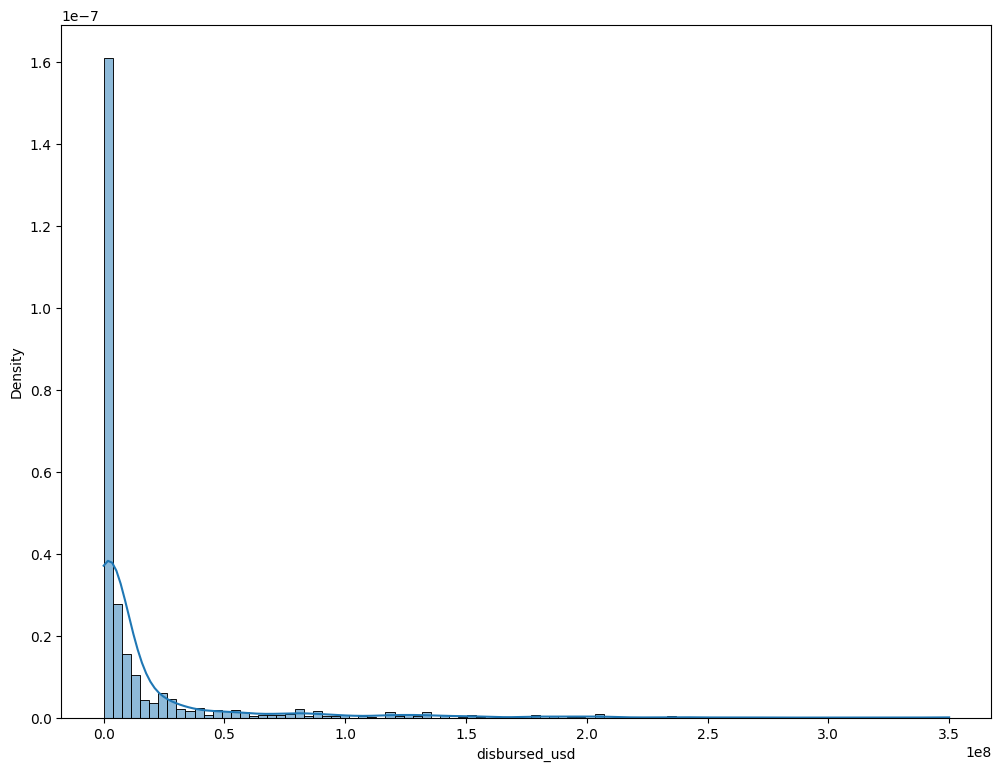

In [7]:
from matplotlib import pyplot as plt
%matplotlib inline

import seaborn as sns
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.histplot(gbtp_alcns_adj_df['disbursed_usd'], stat='density',kde=True)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'Colombia'),
  Text(1, 0, 'Mexico'),
  Text(2, 0, 'Brazil'),
  Text(3, 0, 'Costa Rica'),
  Text(4, 0, 'Peru'),
  Text(5, 0, 'Honduras'),
  Text(6, 0, 'Nicaragua'),
  Text(7, 0, 'Chile'),
  Text(8, 0, 'Panama'),
  Text(9, 0, 'El Salvador'),
  Text(10, 0, 'Argentina'),
  Text(11, 0, 'Ecuador'),
  Text(12, 0, 'Uruguay'),
  Text(13, 0, 'Dominican Republic'),
  Text(14, 0, 'Bolivia'),
  Text(15, 0, 'Barbados')])

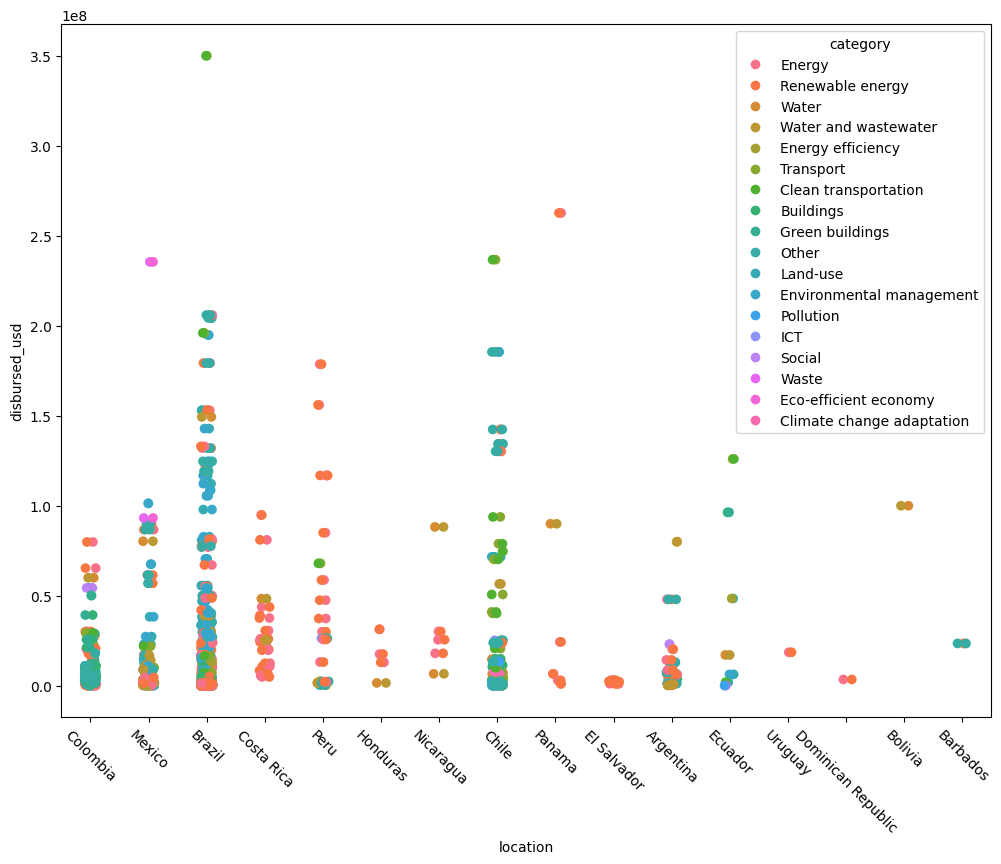

In [8]:
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.stripplot(x='location', y='disbursed_usd', data= gbtp_alcns_adj_df, hue='category', size=7)
plt.xticks(rotation=-45)

<Axes: xlabel='disbursed_usd', ylabel='location'>

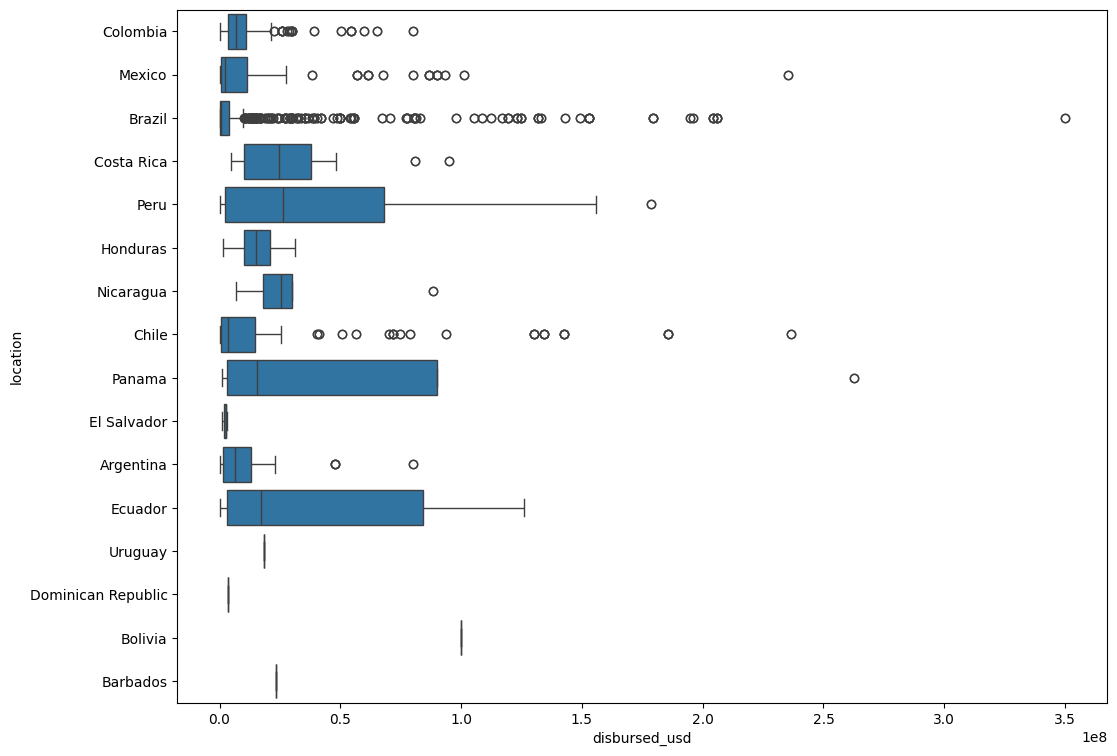

In [9]:
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.boxplot(gbtp_alcns_adj_df, x='disbursed_usd', y='location')

In [12]:
in_scope_handles = pd.read_excel('/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/inScopeHandles.xlsx')
in_scope_handle_df = pd.DataFrame(in_scope_handles)
in_scope_handle_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  137 non-null    int64
 1   Handle      137 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.3 KB


In [14]:
gbtp_alcns_adj_df['In scope'] = gbtp_alcns_adj_df['bond_handle'].isin(in_scope_handle_df['Handle'])
gbtp_alcns_adj_df.info()

<class 'pandas.DataFrame'>
Index: 2138 entries, 0 to 2277
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   bond_handle                    2138 non-null   str    
 1   bond_name                      2138 non-null   str    
 2   nomenclature                   2138 non-null   str    
 3   category                       2138 non-null   str    
 4   subcategory                    2138 non-null   str    
 5   project                        2138 non-null   str    
 6   location                       2138 non-null   str    
 7   date_allocation                2138 non-null   str    
 8   date_disbursement              2138 non-null   str    
 9   allocation_currency            2138 non-null   str    
 10  allocated_allocation_currency  2138 non-null   float64
 11  disbursed_allocation_currency  2138 non-null   float64
 12  bond_currency                  2138 non-null   str    
 13  disb

In [17]:
import openpyxl

gbtp_alcns_adj_df.to_excel('/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/inScopeAllocations.xlsx')


In [16]:
gbtp_alcns_inscope_df = gbtp_alcns_adj_df['In scope']==True
gbtp_alcns_inscope_df.head()

0    False
1    False
2    False
3    False
4    False
Name: In scope, dtype: bool